# Notebook 02 — Preprocessing & Label Engineering
**Goal:** Clean raw tweet text, run TF-IDF + K-Means to discover natural issue clusters, assign human-readable labels, add priority scores via sentiment analysis.

In [2]:
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

## 1. Load Inbound Tickets

In [4]:
df = pd.read_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/processed/inbound_tickets.csv')
print(f'Loaded {len(df):,} inbound tickets')
df.head(3)

Loaded 1,756,997 inbound tickets


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_length,word_count,date,hour
0,2,115712,True,2017-10-31 22:11:45+00:00,@sprintcare and how do you propose we do that,NaN,1.0,45.0,9.0,2017-10-31,22.0
1,3,115712,True,2017-10-31 22:08:27+00:00,@sprintcare I have sent several private messag...,1,4.0,82.0,14.0,2017-10-31,22.0
2,5,115712,True,2017-10-31 21:49:35+00:00,@sprintcare I did.,4,6.0,18.0,3.0,2017-10-31,21.0


## 2. Text Cleaning

In [5]:
def clean_text(text):
    """Clean tweet text for NLP processing."""
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)          # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)      # keep hashtag words, drop #
    text = re.sub(r'[^a-z\s]', ' ', text)      # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Drop rows with very short cleaned text (less than 3 words)
df = df[df['clean_text'].apply(lambda x: len(x.split()) >= 3)].copy()
print(f'After filtering short texts: {len(df):,} rows')

# Preview
pd.DataFrame({'original': df['text'].head(5).values,
              'cleaned': df['clean_text'].head(5).values})

After filtering short texts: 1,501,325 rows


,original,cleaned
0,@sprintcare and how do you propose we do that,and how do you propose we do that
1,@sprintcare I have sent several private messag...,i have sent several private messages and no on...
2,@sprintcare is the worst customer service,is the worst customer service
3,@sprintcare You gonna magically change your co...,you gonna magically change your connectivity f...
4,@sprintcare Since I signed up with you....Sinc...,since i signed up with you since day


## 3. TF-IDF Vectorization
We use a sample of 80K tickets for clustering (full dataset is very large). Increase if your machine handles it.

In [6]:
SAMPLE_SIZE = 80000
sample_df = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42).copy()
print(f'Clustering on {len(sample_df):,} tickets')

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words='english'
)

X = tfidf.fit_transform(sample_df['clean_text'])
print(f'TF-IDF matrix shape: {X.shape}')

Clustering on 80,000 tickets
TF-IDF matrix shape: (80000, 5000)


## 4. Find Optimal K — Elbow Method

  K=3 done
  K=4 done
  K=5 done
  K=6 done
  K=7 done
  K=8 done
  K=9 done
  K=10 done
  K=11 done


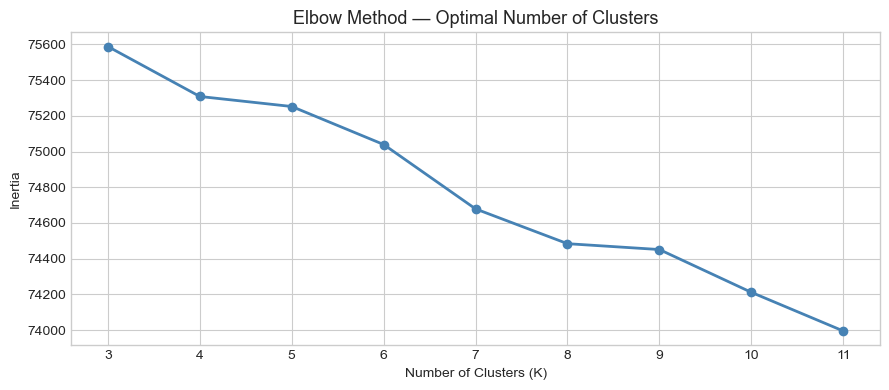

In [7]:
inertias = []
K_range = range(3, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f'  K={k} done')

plt.figure(figsize=(9, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

## 5. Fit Final K-Means (K=6)
Based on the elbow curve. Adjust K if your elbow falls at a different point.

In [8]:
K = 6
km_final = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
sample_df['cluster'] = km_final.fit_predict(X)

# Show top keywords per cluster to understand what each cluster represents
feature_names = tfidf.get_feature_names_out()
order_centroids = km_final.cluster_centers_.argsort()[:, ::-1]

print('=== TOP KEYWORDS PER CLUSTER ===')
for i in range(K):
    top_terms = [feature_names[ind] for ind in order_centroids[i, :15]]
    print(f'\nCluster {i}: {" | ".join(top_terms)}')

=== TOP KEYWORDS PER CLUSTER ===

Cluster 0: help | service | customer | customer service | need | need help | phone | account | worst | just | ve | hi | great | thank | amp

Cluster 1: thanks | dm | just | reply | help | hi | thanks help | great | sent | response | thanks reply | ll | ok | flight | got

Cluster 2: home | wifi | work | flight | just | amp | phone | got | internet | got home | working | going | thanks | service | today

Cluster 3: time | just | ve | don | amp | phone | delivery | flight | order | like | second time | day | long | today | second

Cluster 4: just | thank | phone | don | like | ve | amp | got | fix | need | account | flight | new | did | going

Cluster 5: confirm order | order delivered | confirm | delivered | order | thx | wednesday | sold | send | hey | update | frame | france | fraud | fraudulent


## 6. Assign Human-Readable Labels

Here's the mapping based on what I see:

#### Cluster 0 → general_complaint
Keywords: help, service, customer, worst, account, phone. This is general frustration — people venting or asking for help without a specific issue.

#### Cluster 1 → general_inquiry

Keywords: thanks, dm, reply, sent, response, flight. This is back-and-forth conversation — people following up or asking simple questions.

#### Cluster 2 → technical_issue

Keywords: wifi, work, internet, working, phone, home. Clear technical problems — connectivity, device issues.

#### Cluster 3 → shipping_delivery

Keywords: delivery, order, time, long, day, second time. Delivery delays and order timing complaints.

#### Cluster 4 → account_access

Keywords: fix, account, need, don, phone, going. Account problems and things needing to be fixed.

#### Cluster 5 → billing_payment

Keywords: confirm order, order delivered, fraud, fraudulent, sold, update. Billing, order confirmation, and fraud signals.

account_access       60977
general_complaint     7241
general_inquiry       3524
shipping_delivery     3503
billing_payment       3173
technical_issue       1582
Name: category, dtype: int64


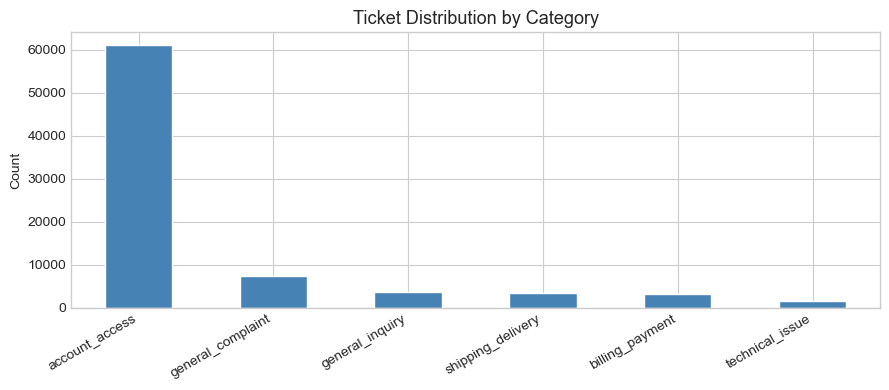

In [9]:
# !! EDIT THIS MAPPING after reviewing cluster keywords above !!
CLUSTER_LABELS = {
    0: 'general_complaint',
    1: 'general_inquiry',
    2: 'technical_issue',
    3: 'shipping_delivery',
    4: 'account_access',
    5: 'billing_payment'
}

sample_df['category'] = sample_df['cluster'].map(CLUSTER_LABELS)

# Distribution
cat_counts = sample_df['category'].value_counts()
print(cat_counts)

plt.figure(figsize=(9, 4))
cat_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Ticket Distribution by Category', fontsize=13)
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

## 7. Sample Tickets Per Category
Sanity-check that the labels make sense.

In [10]:
for cat in CLUSTER_LABELS.values():
    subset = sample_df[sample_df['category'] == cat]['text'].sample(3, random_state=1)
    print(f'\n--- {cat.upper()} ---')
    for t in subset:
        print(f'  • {t}')


--- GENERAL_COMPLAINT ---
  • @GWRHelp Superb response from @GWRHelp almost as good as their customer service and demonstrable of their commitment to keeping customers happy.
  • @TMobileHelp @215615 I got a free rental to vudu but it didn't go to my account and says redeemed.... help please.
  • @AppleSupport Yeah that seems to have done it, thank you very much for your help.

--- GENERAL_INQUIRY ---
  • @118541 @719094 will the crowne plaza at the panama airport take US govt ID for the best rate? thanks
  • @SpotifyCares Okay thanks so much for the help!!
  • @SpotifyCares Say no more.. thanks for responding.

--- TECHNICAL_ISSUE ---
  • Man, @115850 delivery guy came home and delivered a book at this hour in these rains. Offered him shelter, tea, fresh clothes - refuses :(
  • Does anyone know why my wifi is working fine on @116230 but not @115858 devices and what I can do to fix it?? #drivingmecrazy
  • @116062 #fail closed I always do my Black Friday shopping 430am and then get m

## 8. Priority Scoring via Sentiment (VADER)
High negativity + urgency keywords → Priority 3 (escalate)
Neutral/mild → Priority 2
Low urgency → Priority 1

Priority distribution:
1    65204
2     9163
3     5633
Name: priority, dtype: int64


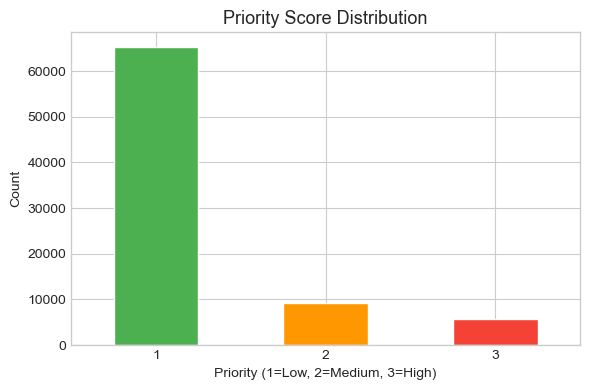

In [11]:
analyzer = SentimentIntensityAnalyzer()

URGENCY_KEYWORDS = [
    'urgent', 'asap', 'immediately', 'emergency', 'critical',
    'fraud', 'hacked', 'stolen', 'broken', 'cant access',
    'not working', 'outage', 'down', 'error', 'failed'
]

def get_priority(text):
    scores = analyzer.polarity_scores(str(text))
    neg_score = scores['neg']
    text_lower = str(text).lower()
    has_urgency = any(kw in text_lower for kw in URGENCY_KEYWORDS)

    if has_urgency or neg_score > 0.5:
        return 3  # High — escalate
    elif neg_score > 0.2:
        return 2  # Medium
    else:
        return 1  # Low

sample_df['priority'] = sample_df['text'].apply(get_priority)
sample_df['sentiment_neg'] = sample_df['text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['neg']
)

print('Priority distribution:')
print(sample_df['priority'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sample_df['priority'].value_counts().sort_index().plot(
    kind='bar', color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white'
)
plt.title('Priority Score Distribution', fontsize=13)
plt.xlabel('Priority (1=Low, 2=Medium, 3=High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 9. PCA Visualization of Clusters

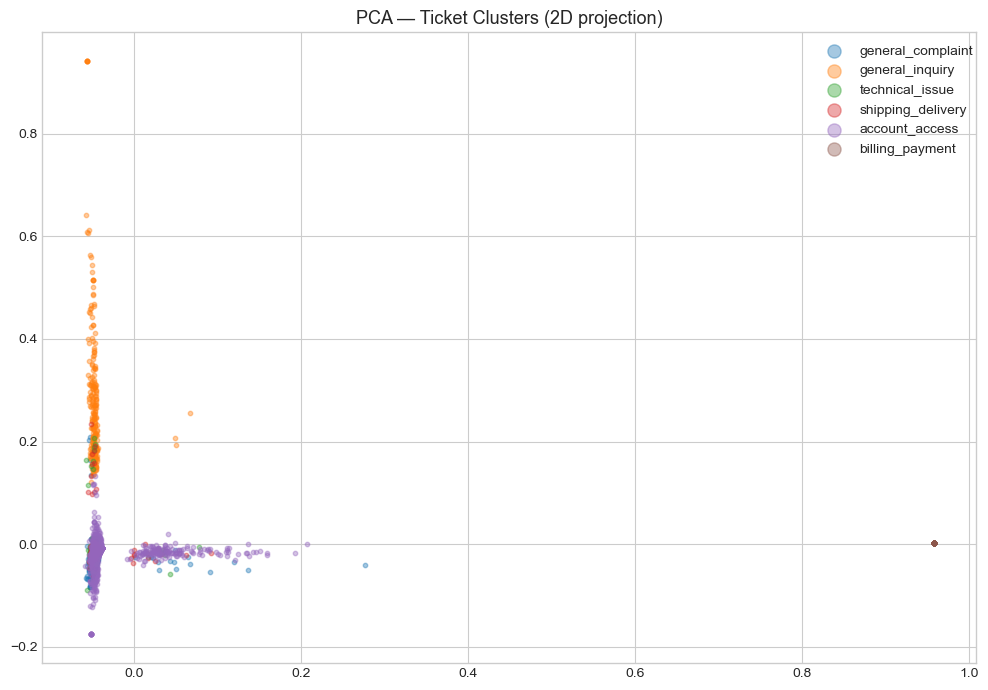

In [12]:
# Reduce to 2D for visualization (sample 5k for speed)
viz_idx = sample_df.sample(5000, random_state=42).index
X_viz = X[sample_df.index.get_indexer(viz_idx)]

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_viz.toarray())

viz_df = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
viz_df['category'] = sample_df.loc[viz_idx, 'category'].values

plt.figure(figsize=(10, 7))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
for i, cat in enumerate(CLUSTER_LABELS.values()):
    subset = viz_df[viz_df['category'] == cat]
    plt.scatter(subset['PC1'], subset['PC2'], label=cat,
                alpha=0.4, s=10, color=colors[i])

plt.title('PCA — Ticket Clusters (2D projection)', fontsize=13)
plt.legend(markerscale=3, bbox_to_anchor=(1.01, 1))
plt.tight_layout()

plt.show()

## 10. Save Labeled Dataset + Load into SQLite

In [13]:
# Keep only what we need
final_cols = ['tweet_id', 'author_id', 'created_at', 'text', 'clean_text',
              'category', 'priority', 'sentiment_neg', 'text_length', 'word_count']
available_cols = [c for c in final_cols if c in sample_df.columns]
labeled = sample_df[available_cols].copy()

# Save CSV
labeled.to_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/processed/labeled_tickets.csv', index=False)
print(f'Saved labeled CSV: {len(labeled):,} rows')

# Load into SQLite
conn = sqlite3.connect('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/support_tickets.db')

# Execute schema first
with open('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/sql/schema.sql', 'r') as f:
    conn.executescript(f.read())

# Insert tickets
labeled.to_sql('tickets', conn, if_exists='replace', index=False)
conn.commit()

row_count = conn.execute('SELECT COUNT(*) FROM tickets').fetchone()[0]
print(f'SQLite tickets table: {row_count:,} rows')
conn.close()

Saved labeled CSV: 80,000 rows
SQLite tickets table: 80,000 rows


## Summary
- Loaded 1,756,997 inbound customer tickets from Notebook 01
- Cleaned tweet text: removed @mentions, URLs, emojis, punctuation, lowercased
- Sampled 80,000 tweets for clustering (representative, computationally feasible)
- TF-IDF vectorized text (5,000 features, bigrams) → K-Means clustering (K=6)
- Elbow method tested K=3 to K=11 — K=6 selected for business interpretability
- Discovered 6 natural issue categories:
    general_complaint | general_inquiry | technical_issue |
    shipping_delivery | account_access  | billing_payment
- Priority scores assigned (1-3) using VADER sentiment + urgency keyword detection
- 80,000 labeled tickets saved to labeled_tickets.csv and SQLite tickets table
- Next: Notebook 03 — Baseline ML classifier (TF-IDF + Logistic Regression + Random Forest)